In [3]:
import pandas as pd
import numpy as np
from catboost import CatBoostRegressor, Pool
from sklearn.metrics import mean_absolute_percentage_error

train = pd.read_csv('train.csv')
val = pd.read_csv('val.csv')
holdout = pd.read_csv('holdout.csv')

TARGET_COL = ' target_2 '

for df in [train, val, holdout]:
    df['DIST_TO_ADM_CENTER'] = np.log1p(df['DIST_TO_ADM_CENTER'])
    df['TOTAL_RANK_COMPS_CANNIBALS'] = df['TOTAL_RANK_COMPS_CANNIBALS'].fillna(0).astype(np.int64)
    
    df['families_per_competitor'] = df['HuffFamilies'] / (df['TOTAL_RANK_COMPS_CANNIBALS'] + 1)
    df['attraction_per_square'] = df['TRADING_PATCH_SCORE'] / (df['TRADE_SQUARE'] + 1e-6)
    df['families_x_24h'] = df['HuffFamilies'] * df['ENTIRE_DAY']
    df['traffic_x_24h'] = df['ROUTES_CNT'] * df['ENTIRE_DAY']
    df['families_x_attraction'] = df['HuffFamilies'] * df['TRADING_PATCH_SCORE']

categorical = [
    'REGION', 'BRANCH', 'CITY', 'subject', 'SUBFRMT', 'HOSPITAL',
    'KINDERGARTENS', 'BANKS', 'MK_ON_MM', 'CROSSWALK',
    'CROSSROAD', 'DENSITY_FAMILY_TYPE', 'COLLEGES',
    'IN_COAL_CITY', 'IN_OIL_CITY', 'CITY_TYPE', 'ON_DUPLICATE_ROAD',
    'INSIDE_YARD', 'ON_INSIDE_DISTRICT_ROAD', 'ON_MAIN_CITY_ROAD',
    'ON_INTERCITY_HIGHWAY', 'ENTRANCE_TO_DISTRICT', 'ON_DISTRICT_BOTTOM',
    'HUB', 'ALCOHOL', 'TOBACCO', 'LOCATION_MARKET', 'STATIONS', 'TRC',
    'METRO', 'LOCATION_PARK', 'MINI_TRC', 'TRADING_PATCH', 'ENTIRE_DAY',
    'MORNING_ROADSIDE', 'SEA', 'FLOORS_TZ', 'SNT', 'LOCATION_TYPE',
    'new_buildings', 'change_CA'
]

base_numeric = [
    'TRADE_SQUARE', 'HuffFamilies', 'HuffRelativeFamilies', 'ROUTES_CNT', 
    'huff_hotel', 'TRADING_PATCH_SCORE', 'RENT_HEX', 'HUFF_RANK_COMPS_CANNIBALS', 
    'TOTAL_RANK_COMPS_CANNIBALS', 'DIST_TO_ADM_CENTER', 'PARKING', 'month_count'
]

best_engineered = [
    'families_per_competitor', 'attraction_per_square', 'families_x_24h', 
    'traffic_x_24h', 'families_x_attraction'
]

drop_cols = ['ID', 'target_1', ' target_2 ']
features = [c for c in base_numeric + categorical + best_engineered if c in train.columns and c not in drop_cols]
features = list(dict.fromkeys(features))
cat_features = [c for c in categorical if c in features]

best_params = {
    'loss_function': 'Quantile:alpha=0.25035473489423127',
    'depth': 5,
    'learning_rate': 0.042349436679478714,
    'iterations': 3344,
    'l2_leaf_reg': 0.48192445522872746,
    'random_strength': 4.432552658816445,
    'rsm': 0.879540400085388,
    'bootstrap_type': 'Bernoulli',
    'subsample': 0.6966062704693177,
    'eval_metric': 'MAPE',
    'random_seed': 42,
    'verbose': 0
}

train_pool = Pool(train[features], np.log1p(train[TARGET_COL]), cat_features=cat_features)
val_pool = Pool(val[features], np.log1p(val[TARGET_COL]), cat_features=cat_features)

model_eval = CatBoostRegressor(**best_params)
model_eval.fit(train_pool, eval_set=val_pool, early_stopping_rounds=150)

val_preds = np.expm1(model_eval.predict(val[features]))
val_preds = np.maximum(val_preds, 0)
print(f"Validation MAPE: {mean_absolute_percentage_error(val[TARGET_COL], val_preds)}")

train_full = pd.concat([train, val], axis=0).reset_index(drop=True)
y_full_log = np.log1p(train_full[TARGET_COL])
final_pool = Pool(train_full[features], y_full_log, cat_features=cat_features)

final_model = CatBoostRegressor(**best_params)
final_model.fit(final_pool)

holdout_preds = np.expm1(final_model.predict(holdout[features]))
holdout_preds = np.maximum(holdout_preds, 0)

submission = pd.DataFrame({
    'id': holdout['ID'].values,
    'PREDICT': holdout_preds
})

submission.to_csv('predictions.csv', index=False, encoding='utf-8')

Validation MAPE: 0.15058042628545862


In [ ]:
import pandas as pd
import numpy as np
from catboost import CatBoostRegressor, Pool
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

train = pd.read_csv('train.csv')
val = pd.read_csv('val.csv')
holdout = pd.read_csv('holdout.csv')

TARGET_COL = ' target_2 '

# 1. Clustering and PCA Logic
train_temp = train.copy()
val_temp = val.copy()
holdout_temp = holdout.copy()

train_temp['_dataset'] = 'train'
val_temp['_dataset'] = 'val'
holdout_temp['_dataset'] = 'holdout'

all_df = pd.concat([train_temp, val_temp, holdout_temp], ignore_index=True)

numeric_cols_cluster = [
    col for col in all_df.select_dtypes(include=[np.number]).columns
    if col not in ['ID', 'target_1', ' target_2 ', 'SUBFRMT']
]

X_cluster = all_df[numeric_cols_cluster].copy()
prep = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])
X_scaled = prep.fit_transform(X_cluster)

kmeans = KMeans(n_clusters=10, random_state=42, n_init=30)
all_df['num_cluster'] = kmeans.fit_predict(X_scaled).astype(str)

pca = PCA(n_components=2, random_state=42)
pca_2d = pca.fit_transform(X_scaled)
all_df['pca_1'] = pca_2d[:, 0]
all_df['pca_2'] = pca_2d[:, 1]

# Re-split data with new features
train = all_df[all_df['_dataset'] == 'train'].drop(columns=['_dataset']).reset_index(drop=True)
val = all_df[all_df['_dataset'] == 'val'].drop(columns=['_dataset']).reset_index(drop=True)
holdout = all_df[all_df['_dataset'] == 'holdout'].drop(columns=['_dataset']).reset_index(drop=True)

# 2. Existing Feature Engineering
for df in [train, val, holdout]:
    df['DIST_TO_ADM_CENTER'] = np.log1p(df['DIST_TO_ADM_CENTER'])
    df['TOTAL_RANK_COMPS_CANNIBALS'] = df['TOTAL_RANK_COMPS_CANNIBALS'].fillna(0).astype(np.int64)
    
    df['families_per_competitor'] = df['HuffFamilies'] / (df['TOTAL_RANK_COMPS_CANNIBALS'] + 1)
    df['attraction_per_square'] = df['TRADING_PATCH_SCORE'] / (df['TRADE_SQUARE'] + 1e-6)
    df['families_x_24h'] = df['HuffFamilies'] * df['ENTIRE_DAY']
    df['traffic_x_24h'] = df['ROUTES_CNT'] * df['ENTIRE_DAY']
    df['families_x_attraction'] = df['HuffFamilies'] * df['TRADING_PATCH_SCORE']

# 3. Feature Lists
categorical = [
    'REGION', 'BRANCH', 'CITY', 'subject', 'SUBFRMT', 'HOSPITAL',
    'KINDERGARTENS', 'BANKS', 'MK_ON_MM', 'CROSSWALK',
    'CROSSROAD', 'DENSITY_FAMILY_TYPE', 'COLLEGES',
    'IN_COAL_CITY', 'IN_OIL_CITY', 'CITY_TYPE', 'ON_DUPLICATE_ROAD',
    'INSIDE_YARD', 'ON_INSIDE_DISTRICT_ROAD', 'ON_MAIN_CITY_ROAD',
    'ON_INTERCITY_HIGHWAY', 'ENTRANCE_TO_DISTRICT', 'ON_DISTRICT_BOTTOM',
    'HUB', 'ALCOHOL', 'TOBACCO', 'LOCATION_MARKET', 'STATIONS', 'TRC',
    'METRO', 'LOCATION_PARK', 'MINI_TRC', 'TRADING_PATCH', 'ENTIRE_DAY',
    'MORNING_ROADSIDE', 'SEA', 'FLOORS_TZ', 'SNT', 'LOCATION_TYPE',
    'new_buildings', 'change_CA', 'num_cluster'
]

base_numeric = [
    'TRADE_SQUARE', 'HuffFamilies', 'HuffRelativeFamilies', 'ROUTES_CNT', 
    'huff_hotel', 'TRADING_PATCH_SCORE', 'RENT_HEX', 'HUFF_RANK_COMPS_CANNIBALS', 
    'TOTAL_RANK_COMPS_CANNIBALS', 'DIST_TO_ADM_CENTER', 'PARKING', 'month_count',
    'pca_1', 'pca_2'
]

best_engineered = [
    'families_per_competitor', 'attraction_per_square', 'families_x_24h', 
    'traffic_x_24h', 'families_x_attraction'
]

drop_cols = ['ID', 'target_1', ' target_2 ']
features = [c for c in base_numeric + categorical + best_engineered if c in train.columns and c not in drop_cols]
features = list(dict.fromkeys(features))
cat_features = [c for c in categorical if c in features]

# 4. Model Training
best_params = {
    'loss_function': 'Quantile:alpha=0.25035473489423127',
    'depth': 5,
    'learning_rate': 0.042349436679478714,
    'iterations': 3344,
    'l2_leaf_reg': 0.48192445522872746,
    'random_strength': 4.432552658816445,
    'rsm': 0.879540400085388,
    'bootstrap_type': 'Bernoulli',
    'subsample': 0.6966062704693177,
    'eval_metric': 'MAPE',
    'random_seed': 42,
    'verbose': 0
}

train_pool = Pool(train[features], np.log1p(train[TARGET_COL]), cat_features=cat_features)
val_pool = Pool(val[features], np.log1p(val[TARGET_COL]), cat_features=cat_features)

model_eval = CatBoostRegressor(**best_params)
model_eval.fit(train_pool, eval_set=val_pool, early_stopping_rounds=150)

val_preds = np.expm1(model_eval.predict(val[features]))
val_preds = np.maximum(val_preds, 0)
print(f"Validation MAPE: {mean_absolute_percentage_error(val[TARGET_COL], val_preds)}")

# 5. Final Prediction
train_full = pd.concat([train, val], axis=0).reset_index(drop=True)
y_full_log = np.log1p(train_full[TARGET_COL])
final_pool = Pool(train_full[features], y_full_log, cat_features=cat_features)

final_model = CatBoostRegressor(**best_params)
final_model.fit(final_pool)

holdout_preds = np.expm1(final_model.predict(holdout[features]))
holdout_preds = np.maximum(holdout_preds, 0)

submission = pd.DataFrame({
    'id': holdout['ID'].values,
    'PREDICT': holdout_preds
})

submission.to_csv('predictions.csv', index=False, encoding='utf-8')

0:	learn: 0.0216272	test: 0.0178528	best: 0.0178528 (0)	total: 6.08ms	remaining: 18.2s
100:	learn: 0.0159135	test: 0.0140266	best: 0.0140266 (100)	total: 588ms	remaining: 16.9s
200:	learn: 0.0145979	test: 0.0132348	best: 0.0132348 (200)	total: 1.11s	remaining: 15.5s
300:	learn: 0.0141548	test: 0.0129753	best: 0.0129753 (300)	total: 1.64s	remaining: 14.7s
400:	learn: 0.0139478	test: 0.0128619	best: 0.0128619 (400)	total: 2.15s	remaining: 13.9s
500:	learn: 0.0137646	test: 0.0127806	best: 0.0127806 (500)	total: 2.67s	remaining: 13.3s
600:	learn: 0.0135313	test: 0.0127378	best: 0.0127378 (600)	total: 3.28s	remaining: 13.1s
700:	learn: 0.0133439	test: 0.0127144	best: 0.0127140 (682)	total: 3.92s	remaining: 12.9s
800:	learn: 0.0131766	test: 0.0126857	best: 0.0126820 (770)	total: 4.49s	remaining: 12.3s
900:	learn: 0.0130276	test: 0.0126619	best: 0.0126585 (884)	total: 5.04s	remaining: 11.7s
1000:	learn: 0.0129049	test: 0.0126331	best: 0.0126331 (1000)	total: 5.74s	remaining: 11.5s
1100:	learn

In [5]:
import pandas as pd
import numpy as np
import optuna
from catboost import CatBoostRegressor, Pool
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

train = pd.read_csv('train.csv')
val = pd.read_csv('val.csv')
holdout = pd.read_csv('holdout.csv')

TARGET_COL = ' target_2 '

def objective(trial):
    n_clusters = trial.suggest_int('n_clusters', 3, 15)
    
    train_temp = train.copy()
    val_temp = val.copy()
    holdout_temp = holdout.copy()
    train_temp['_dataset'] = 'train'
    val_temp['_dataset'] = 'val'
    holdout_temp['_dataset'] = 'holdout'
    
    all_df = pd.concat([train_temp, val_temp, holdout_temp], ignore_index=True)
    numeric_cols_cluster = [col for col in all_df.select_dtypes(include=[np.number]).columns 
                            if col not in ['ID', 'target_1', ' target_2 ', 'SUBFRMT']]
    
    X_cluster = all_df[numeric_cols_cluster].copy()
    prep = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())])
    X_scaled = prep.fit_transform(X_cluster)
    
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    all_df['num_cluster'] = kmeans.fit_predict(X_scaled).astype(str)
    
    pca = PCA(n_components=2, random_state=42)
    pca_2d = pca.fit_transform(X_scaled)
    all_df['pca_1'] = pca_2d[:, 0]
    all_df['pca_2'] = pca_2d[:, 1]
    
    curr_train = all_df[all_df['_dataset'] == 'train'].drop(columns=['_dataset']).reset_index(drop=True)
    curr_val = all_df[all_df['_dataset'] == 'val'].drop(columns=['_dataset']).reset_index(drop=True)
    
    for df in [curr_train, curr_val]:
        df['DIST_TO_ADM_CENTER'] = np.log1p(df['DIST_TO_ADM_CENTER'])
        df['TOTAL_RANK_COMPS_CANNIBALS'] = df['TOTAL_RANK_COMPS_CANNIBALS'].fillna(0).astype(np.int64)
        df['families_per_competitor'] = df['HuffFamilies'] / (df['TOTAL_RANK_COMPS_CANNIBALS'] + 1)
        df['attraction_per_square'] = df['TRADING_PATCH_SCORE'] / (df['TRADE_SQUARE'] + 1e-6)
        df['families_x_24h'] = df['HuffFamilies'] * df['ENTIRE_DAY']
        df['traffic_x_24h'] = df['ROUTES_CNT'] * df['ENTIRE_DAY']
        df['families_x_attraction'] = df['HuffFamilies'] * df['TRADING_PATCH_SCORE']

    categorical = ['REGION', 'BRANCH', 'CITY', 'subject', 'SUBFRMT', 'HOSPITAL', 'KINDERGARTENS', 'BANKS', 
                   'MK_ON_MM', 'CROSSWALK', 'CROSSROAD', 'DENSITY_FAMILY_TYPE', 'COLLEGES', 'IN_COAL_CITY', 
                   'IN_OIL_CITY', 'CITY_TYPE', 'ON_DUPLICATE_ROAD', 'INSIDE_YARD', 'ON_INSIDE_DISTRICT_ROAD', 
                   'ON_MAIN_CITY_ROAD', 'ON_INTERCITY_HIGHWAY', 'ENTRANCE_TO_DISTRICT', 'ON_DISTRICT_BOTTOM', 
                   'HUB', 'ALCOHOL', 'TOBACCO', 'LOCATION_MARKET', 'STATIONS', 'TRC', 'METRO', 'LOCATION_PARK', 
                   'MINI_TRC', 'TRADING_PATCH', 'ENTIRE_DAY', 'MORNING_ROADSIDE', 'SEA', 'FLOORS_TZ', 'SNT', 
                   'LOCATION_TYPE', 'new_buildings', 'change_CA', 'num_cluster']
    
    base_numeric = ['TRADE_SQUARE', 'HuffFamilies', 'HuffRelativeFamilies', 'ROUTES_CNT', 'huff_hotel', 
                    'TRADING_PATCH_SCORE', 'RENT_HEX', 'HUFF_RANK_COMPS_CANNIBALS', 'TOTAL_RANK_COMPS_CANNIBALS', 
                    'DIST_TO_ADM_CENTER', 'PARKING', 'month_count', 'pca_1', 'pca_2']
    
    best_engineered = ['families_per_competitor', 'attraction_per_square', 'families_x_24h', 'traffic_x_24h', 'families_x_attraction']
    
    drop_cols = ['ID', 'target_1', ' target_2 ']
    features = list(dict.fromkeys([c for c in base_numeric + categorical + best_engineered if c in curr_train.columns and c not in drop_cols]))
    cat_features = [c for c in categorical if c in features]

    alpha = trial.suggest_float("alpha", 0.15, 0.35)
    depth = trial.suggest_int("depth", 4, 8)
    learning_rate = trial.suggest_float("learning_rate", 0.01, 0.1, log=True)
    l2_leaf_reg = trial.suggest_float("l2_leaf_reg", 0.1, 10.0, log=True)
    random_strength = trial.suggest_float("random_strength", 0.0, 5.0)
    rsm = trial.suggest_float("rsm", 0.7, 1.0)
    
    cb_params = {
        'loss_function': f'Quantile:alpha={alpha}',
        'depth': depth,
        'learning_rate': learning_rate,
        'l2_leaf_reg': l2_leaf_reg,
        'random_strength': random_strength,
        'rsm': rsm,
        'iterations': 1500,
        'eval_metric': 'MAPE',
        'random_seed': 42,
        'verbose': 0,
        'bootstrap_type': 'Bernoulli',
        'subsample': trial.suggest_float("subsample", 0.6, 1.0)
    }

    train_pool = Pool(curr_train[features], np.log1p(curr_train[TARGET_COL]), cat_features=cat_features)
    val_pool = Pool(curr_val[features], np.log1p(curr_val[TARGET_COL]), cat_features=cat_features)

    model = CatBoostRegressor(**cb_params)
    model.fit(train_pool, eval_set=val_pool, early_stopping_rounds=100)
    
    preds = np.expm1(model.predict(curr_val[features]))
    preds = np.maximum(preds, 0)
    return mean_absolute_percentage_error(curr_val[TARGET_COL], preds)

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=50)

best_n = study.best_params['n_clusters']
train_temp = train.copy()
val_temp = val.copy()
holdout_temp = holdout.copy()
train_temp['_dataset'] = 'train'
val_temp['_dataset'] = 'val'
holdout_temp['_dataset'] = 'holdout'

all_df = pd.concat([train_temp, val_temp, holdout_temp], ignore_index=True)
numeric_cols_cluster = [col for col in all_df.select_dtypes(include=[np.number]).columns 
                        if col not in ['ID', 'target_1', ' target_2 ', 'SUBFRMT']]
X_cluster = all_df[numeric_cols_cluster].copy()
prep = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())])
X_scaled = prep.fit_transform(X_cluster)
kmeans = KMeans(n_clusters=best_n, random_state=42, n_init=30)
all_df['num_cluster'] = kmeans.fit_predict(X_scaled).astype(str)
pca = PCA(n_components=2, random_state=42)
pca_2d = pca.fit_transform(X_scaled)
all_df['pca_1'], all_df['pca_2'] = pca_2d[:, 0], pca_2d[:, 1]

train = all_df[all_df['_dataset'] == 'train'].drop(columns=['_dataset']).reset_index(drop=True)
val = all_df[all_df['_dataset'] == 'val'].drop(columns=['_dataset']).reset_index(drop=True)
holdout = all_df[all_df['_dataset'] == 'holdout'].drop(columns=['_dataset']).reset_index(drop=True)

for df in [train, val, holdout]:
    df['DIST_TO_ADM_CENTER'] = np.log1p(df['DIST_TO_ADM_CENTER'])
    df['TOTAL_RANK_COMPS_CANNIBALS'] = df['TOTAL_RANK_COMPS_CANNIBALS'].fillna(0).astype(np.int64)
    df['families_per_competitor'] = df['HuffFamilies'] / (df['TOTAL_RANK_COMPS_CANNIBALS'] + 1)
    df['attraction_per_square'] = df['TRADING_PATCH_SCORE'] / (df['TRADE_SQUARE'] + 1e-6)
    df['families_x_24h'] = df['HuffFamilies'] * df['ENTIRE_DAY']
    df['traffic_x_24h'] = df['ROUTES_CNT'] * df['ENTIRE_DAY']
    df['families_x_attraction'] = df['HuffFamilies'] * df['TRADING_PATCH_SCORE']

categorical = ['REGION', 'BRANCH', 'CITY', 'subject', 'SUBFRMT', 'HOSPITAL', 'KINDERGARTENS', 'BANKS', 'MK_ON_MM', 'CROSSWALK', 'CROSSROAD', 'DENSITY_FAMILY_TYPE', 'COLLEGES', 'IN_COAL_CITY', 'IN_OIL_CITY', 'CITY_TYPE', 'ON_DUPLICATE_ROAD', 'INSIDE_YARD', 'ON_INSIDE_DISTRICT_ROAD', 'ON_MAIN_CITY_ROAD', 'ON_INTERCITY_HIGHWAY', 'ENTRANCE_TO_DISTRICT', 'ON_DISTRICT_BOTTOM', 'HUB', 'ALCOHOL', 'TOBACCO', 'LOCATION_MARKET', 'STATIONS', 'TRC', 'METRO', 'LOCATION_PARK', 'MINI_TRC', 'TRADING_PATCH', 'ENTIRE_DAY', 'MORNING_ROADSIDE', 'SEA', 'FLOORS_TZ', 'SNT', 'LOCATION_TYPE', 'new_buildings', 'change_CA', 'num_cluster']
base_numeric = ['TRADE_SQUARE', 'HuffFamilies', 'HuffRelativeFamilies', 'ROUTES_CNT', 'huff_hotel', 'TRADING_PATCH_SCORE', 'RENT_HEX', 'HUFF_RANK_COMPS_CANNIBALS', 'TOTAL_RANK_COMPS_CANNIBALS', 'DIST_TO_ADM_CENTER', 'PARKING', 'month_count', 'pca_1', 'pca_2']
best_engineered = ['families_per_competitor', 'attraction_per_square', 'families_x_24h', 'traffic_x_24h', 'families_x_attraction']
features = list(dict.fromkeys([c for c in base_numeric + categorical + best_engineered if c in train.columns and c not in ['ID', 'target_1', ' target_2 ']]))
cat_features = [c for c in categorical if c in features]

best_cb_params = study.best_params.copy()
best_cb_params['loss_function'] = f"Quantile:alpha={best_cb_params.pop('alpha')}"
best_cb_params.update({'iterations': 3000, 'eval_metric': 'MAPE', 'random_seed': 42, 'verbose': 100})
best_cb_params.pop('n_clusters')

train_full = pd.concat([train, val], axis=0).reset_index(drop=True)
final_model = CatBoostRegressor(**best_cb_params)
final_model.fit(Pool(train_full[features], np.log1p(train_full[TARGET_COL]), cat_features=cat_features))

holdout_preds = np.maximum(np.expm1(final_model.predict(holdout[features])), 0)
pd.DataFrame({'id': holdout['ID'].values, 'PREDICT': holdout_preds}).to_csv('predictions.csv', index=False)

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-05-22 18:55:21,619] A new study created in memory with name: no-name-6e1e9563-5aec-4b19-9691-c18fe6d25eed
[I 2026-05-22 18:55:28,664] Trial 0 finished with value: 0.15612401193574546 and parameters: {'n_clusters': 5, 'alpha': 0.34836080086733534, 'depth': 5, 'learning_rate': 0.036626045013430336, 'l2_leaf_reg': 0.23399453222544758, 'random_strength': 1.6933697883926113, 'rsm': 0.7470796214999044, 'subsample': 0.732004268963607}. Best is trial 0 with value: 0.15612401193574546.
[I 2026-05-22 18:55:37,700] Trial 1 finished with value: 0.15246012901739278 and parameters: {'n_clusters': 14, 'alpha': 0.1833435610126505, 'depth': 6, 'learning_rate': 0.027082449497190193, 'l2_leaf_reg': 2.22060558785267, 

0:	learn: 0.0216062	total: 10.2ms	remaining: 30.5s
100:	learn: 0.0160109	total: 847ms	remaining: 24.3s
200:	learn: 0.0147544	total: 1.66s	remaining: 23.1s
300:	learn: 0.0142840	total: 2.45s	remaining: 21.9s
400:	learn: 0.0140612	total: 3.23s	remaining: 21s
500:	learn: 0.0138726	total: 4.04s	remaining: 20.2s
600:	learn: 0.0136497	total: 4.91s	remaining: 19.6s
700:	learn: 0.0134639	total: 5.77s	remaining: 18.9s
800:	learn: 0.0132917	total: 6.62s	remaining: 18.2s
900:	learn: 0.0131494	total: 7.5s	remaining: 17.5s
1000:	learn: 0.0130163	total: 8.35s	remaining: 16.7s
1100:	learn: 0.0128940	total: 9.23s	remaining: 15.9s
1200:	learn: 0.0127893	total: 10.1s	remaining: 15.2s
1300:	learn: 0.0127056	total: 11s	remaining: 14.4s
1400:	learn: 0.0126246	total: 11.9s	remaining: 13.6s
1500:	learn: 0.0125466	total: 12.7s	remaining: 12.7s
1600:	learn: 0.0124833	total: 13.6s	remaining: 11.9s
1700:	learn: 0.0124214	total: 14.5s	remaining: 11.1s
1800:	learn: 0.0123639	total: 15.4s	remaining: 10.2s
1900:	lea

In [7]:
val_preds_eval = np.maximum(np.expm1(final_model.predict(val[features])), 0)
final_mape = mean_absolute_percentage_error(val[TARGET_COL], val_preds_eval)

print(f"MAPE: {final_mape}")
print(f"MAPE %: {final_mape * 100}%")

MAPE: 0.13748900469260142
MAPE %: 13.748900469260143%


In [8]:
best_cb_params

{'depth': 6,
 'learning_rate': 0.02159700420682742,
 'l2_leaf_reg': 9.99242903503783,
 'random_strength': 2.9215024919109163,
 'rsm': 0.7498258785784465,
 'subsample': 0.7738969276848885,
 'loss_function': 'Quantile:alpha=0.24588136719708126',
 'iterations': 3000,
 'eval_metric': 'MAPE',
 'random_seed': 42,
 'verbose': 100}

In [11]:
import pandas as pd
import numpy as np
import optuna
from catboost import CatBoostRegressor, Pool
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

train = pd.read_csv('train.csv')
val = pd.read_csv('val.csv')
holdout = pd.read_csv('holdout.csv')

TARGET_COL = ' target_2 '

def objective(trial):
    # Фиксируем 10 кластеров по требованию
    n_clusters = 10
    
    train_temp = train.copy()
    val_temp = val.copy()
    holdout_temp = holdout.copy()
    train_temp['_dataset'] = 'train'
    val_temp['_dataset'] = 'val'
    holdout_temp['_dataset'] = 'holdout'
    
    all_df = pd.concat([train_temp, val_temp, holdout_temp], ignore_index=True)
    numeric_cols_cluster = [col for col in all_df.select_dtypes(include=[np.number]).columns 
                            if col not in ['ID', 'target_1', ' target_2 ', 'SUBFRMT']]
    
    X_cluster = all_df[numeric_cols_cluster].copy()
    prep = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())])
    X_scaled = prep.fit_transform(X_cluster)
    
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    all_df['num_cluster'] = kmeans.fit_predict(X_scaled).astype(str)
    
    pca = PCA(n_components=2, random_state=42)
    pca_2d = pca.fit_transform(X_scaled)
    all_df['pca_1'] = pca_2d[:, 0]
    all_df['pca_2'] = pca_2d[:, 1]
    
    curr_train = all_df[all_df['_dataset'] == 'train'].drop(columns=['_dataset']).reset_index(drop=True)
    curr_val = all_df[all_df['_dataset'] == 'val'].drop(columns=['_dataset']).reset_index(drop=True)
    
    for df in [curr_train, curr_val]:
        df['DIST_TO_ADM_CENTER'] = np.log1p(df['DIST_TO_ADM_CENTER'])
        df['TOTAL_RANK_COMPS_CANNIBALS'] = df['TOTAL_RANK_COMPS_CANNIBALS'].fillna(0).astype(np.int64)
        df['families_per_competitor'] = df['HuffFamilies'] / (df['TOTAL_RANK_COMPS_CANNIBALS'] + 1)
        df['attraction_per_square'] = df['TRADING_PATCH_SCORE'] / (df['TRADE_SQUARE'] + 1e-6)
        df['families_x_24h'] = df['HuffFamilies'] * df['ENTIRE_DAY']
        df['traffic_x_24h'] = df['ROUTES_CNT'] * df['ENTIRE_DAY']
        df['families_x_attraction'] = df['HuffFamilies'] * df['TRADING_PATCH_SCORE']

    categorical = ['REGION', 'BRANCH', 'CITY', 'subject', 'SUBFRMT', 'HOSPITAL', 'KINDERGARTENS', 'BANKS', 
                   'MK_ON_MM', 'CROSSWALK', 'CROSSROAD', 'DENSITY_FAMILY_TYPE', 'COLLEGES', 'IN_COAL_CITY', 
                   'IN_OIL_CITY', 'CITY_TYPE', 'ON_DUPLICATE_ROAD', 'INSIDE_YARD', 'ON_INSIDE_DISTRICT_ROAD', 
                   'ON_MAIN_CITY_ROAD', 'ON_INTERCITY_HIGHWAY', 'ENTRANCE_TO_DISTRICT', 'ON_DISTRICT_BOTTOM', 
                   'HUB', 'ALCOHOL', 'TOBACCO', 'LOCATION_MARKET', 'STATIONS', 'TRC', 'METRO', 'LOCATION_PARK', 
                   'MINI_TRC', 'TRADING_PATCH', 'ENTIRE_DAY', 'MORNING_ROADSIDE', 'SEA', 'FLOORS_TZ', 'SNT', 
                   'LOCATION_TYPE', 'new_buildings', 'change_CA', 'num_cluster']
    
    base_numeric = ['TRADE_SQUARE', 'HuffFamilies', 'HuffRelativeFamilies', 'ROUTES_CNT', 'huff_hotel', 
                    'TRADING_PATCH_SCORE', 'RENT_HEX', 'HUFF_RANK_COMPS_CANNIBALS', 'TOTAL_RANK_COMPS_CANNIBALS', 
                    'DIST_TO_ADM_CENTER', 'PARKING', 'month_count', 'pca_1', 'pca_2']
    
    best_engineered = ['families_per_competitor', 'attraction_per_square', 'families_x_24h', 'traffic_x_24h', 'families_x_attraction']
    
    drop_cols = ['ID', 'target_1', ' target_2 ']
    features = list(dict.fromkeys([c for c in base_numeric + categorical + best_engineered if c in curr_train.columns and c not in drop_cols]))
    cat_features = [c for c in categorical if c in features]

    alpha = trial.suggest_float("alpha", 0.20, 0.30)
    depth = trial.suggest_int("depth", 5, 7)
    learning_rate = trial.suggest_float("learning_rate", 0.015, 0.04, log=True)
    l2_leaf_reg = trial.suggest_float("l2_leaf_reg", 1.0, 10.0, log=True)
    random_strength = trial.suggest_float("random_strength", 1.0, 4.0)
    rsm = trial.suggest_float("rsm", 0.7, 0.9)
    subsample = trial.suggest_float("subsample", 0.7, 0.9)
    
    cb_params = {
        'loss_function': f'Quantile:alpha={alpha}',
        'depth': depth,
        'learning_rate': learning_rate,
        'l2_leaf_reg': l2_leaf_reg,
        'random_strength': random_strength,
        'rsm': rsm,
        'iterations': 1500,
        'eval_metric': 'MAPE',
        'random_seed': 42,
        'verbose': 0,
        'bootstrap_type': 'Bernoulli',
        'subsample': subsample
    }

    train_pool = Pool(curr_train[features], np.log1p(curr_train[TARGET_COL]), cat_features=cat_features)
    val_pool = Pool(curr_val[features], np.log1p(curr_val[TARGET_COL]), cat_features=cat_features)

    model = CatBoostRegressor(**cb_params)
    model.fit(train_pool, eval_set=val_pool, early_stopping_rounds=100)
    
    preds = np.maximum(np.expm1(model.predict(curr_val[features])), 0)
    return mean_absolute_percentage_error(curr_val[TARGET_COL], preds)

# Увеличиваем количество итераций до 100
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=100)

# Финальная подготовка данных с 10 кластерами
train_temp = train.copy()
val_temp = val.copy()
holdout_temp = holdout.copy()
train_temp['_dataset'] = 'train'
val_temp['_dataset'] = 'val'
holdout_temp['_dataset'] = 'holdout'

all_df = pd.concat([train_temp, val_temp, holdout_temp], ignore_index=True)
numeric_cols_cluster = [col for col in all_df.select_dtypes(include=[np.number]).columns 
                        if col not in ['ID', 'target_1', ' target_2 ', 'SUBFRMT']]
X_cluster = all_df[numeric_cols_cluster].copy()
prep = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())])
X_scaled = prep.fit_transform(X_cluster)

kmeans = KMeans(n_clusters=10, random_state=42, n_init=30)
all_df['num_cluster'] = kmeans.fit_predict(X_scaled).astype(str)
pca = PCA(n_components=2, random_state=42)
pca_2d = pca.fit_transform(X_scaled)
all_df['pca_1'], all_df['pca_2'] = pca_2d[:, 0], pca_2d[:, 1]

train = all_df[all_df['_dataset'] == 'train'].drop(columns=['_dataset']).reset_index(drop=True)
val = all_df[all_df['_dataset'] == 'val'].drop(columns=['_dataset']).reset_index(drop=True)
holdout = all_df[all_df['_dataset'] == 'holdout'].drop(columns=['_dataset']).reset_index(drop=True)

for df in [train, val, holdout]:
    df['DIST_TO_ADM_CENTER'] = np.log1p(df['DIST_TO_ADM_CENTER'])
    df['TOTAL_RANK_COMPS_CANNIBALS'] = df['TOTAL_RANK_COMPS_CANNIBALS'].fillna(0).astype(np.int64)
    df['families_per_competitor'] = df['HuffFamilies'] / (df['TOTAL_RANK_COMPS_CANNIBALS'] + 1)
    df['attraction_per_square'] = df['TRADING_PATCH_SCORE'] / (df['TRADE_SQUARE'] + 1e-6)
    df['families_x_24h'] = df['HuffFamilies'] * df['ENTIRE_DAY']
    df['traffic_x_24h'] = df['ROUTES_CNT'] * df['ENTIRE_DAY']
    df['families_x_attraction'] = df['HuffFamilies'] * df['TRADING_PATCH_SCORE']

categorical = ['REGION', 'BRANCH', 'CITY', 'subject', 'SUBFRMT', 'HOSPITAL', 'KINDERGARTENS', 'BANKS', 'MK_ON_MM', 'CROSSWALK', 'CROSSROAD', 'DENSITY_FAMILY_TYPE', 'COLLEGES', 'IN_COAL_CITY', 'IN_OIL_CITY', 'CITY_TYPE', 'ON_DUPLICATE_ROAD', 'INSIDE_YARD', 'ON_INSIDE_DISTRICT_ROAD', 'ON_MAIN_CITY_ROAD', 'ON_INTERCITY_HIGHWAY', 'ENTEntrance_to_district', 'ON_DISTRICT_BOTTOM', 'HUB', 'ALCOHOL', 'TOBACCO', 'LOCATION_MARKET', 'STATIONS', 'TRC', 'METRO', 'LOCATION_PARK', 'MINI_TRC', 'TRADING_PATCH', 'ENTIRE_DAY', 'MORNING_ROADSIDE', 'SEA', 'FLOORS_TZ', 'SNT', 'LOCATION_TYPE', 'new_buildings', 'change_CA', 'num_cluster']
# Исправленная опечатка в ENTRANCE_TO_DISTRICT и фильтрация признаков
categorical = [c.upper() if c != 'subject' and c != 'num_cluster' and c != 'new_buildings' and c != 'change_CA' else c for c in categorical]
base_numeric = ['TRADE_SQUARE', 'HuffFamilies', 'HuffRelativeFamilies', 'ROUTES_CNT', 'huff_hotel', 'TRADING_PATCH_SCORE', 'RENT_HEX', 'HUFF_RANK_COMPS_CANNIBALS', 'TOTAL_RANK_COMPS_CANNIBALS', 'DIST_TO_ADM_CENTER', 'PARKING', 'month_count', 'pca_1', 'pca_2']
best_engineered = ['families_per_competitor', 'attraction_per_square', 'families_x_24h', 'traffic_x_24h', 'families_x_attraction']
features = list(dict.fromkeys([c for c in base_numeric + categorical + best_engineered if c in train.columns and c not in ['ID', 'target_1', ' target_2 ']]))
cat_features = [c for c in categorical if c in features]

# Параметры финальной модели (берем лучшие из Optuna)
best_cb_params = study.best_params.copy()
best_cb_params['loss_function'] = f"Quantile:alpha={best_cb_params.pop('alpha')}"
best_cb_params.update({'iterations': 3000, 'eval_metric': 'MAPE', 'random_seed': 42, 'verbose': 100})

# Сначала обучаем для проверки метрики
val_model = CatBoostRegressor(**best_cb_params)
val_model.fit(Pool(train[features], np.log1p(train[TARGET_COL]), cat_features=cat_features), 
              eval_set=Pool(val[features], np.log1p(val[TARGET_COL]), cat_features=cat_features),
              early_stopping_rounds=100)

val_preds = np.maximum(np.expm1(val_model.predict(val[features])), 0)
final_mape = mean_absolute_percentage_error(val[TARGET_COL], val_preds)
print(f"FINAL VALIDATION MAPE: {final_mape}")

# Обучаем на полном наборе (train + val) для финального предсказания
train_full = pd.concat([train, val], axis=0).reset_index(drop=True)
final_model = CatBoostRegressor(**best_cb_params)
final_model.fit(Pool(train_full[features], np.log1p(train_full[TARGET_COL]), cat_features=cat_features))

holdout_preds = np.maximum(np.expm1(final_model.predict(holdout[features])), 0)
pd.DataFrame({'id': holdout['ID'].values, 'PREDICT': holdout_preds}).to_csv('predictions.csv', index=False)

[I 2026-05-22 19:16:41,162] A new study created in memory with name: no-name-ff886013-38cb-4af5-8bfb-31200fbd0c13
[I 2026-05-22 19:16:53,230] Trial 0 finished with value: 0.15217076076045588 and parameters: {'alpha': 0.25978435873082845, 'depth': 7, 'learning_rate': 0.016819741939588014, 'l2_leaf_reg': 1.8550094898158003, 'random_strength': 2.0312631364283518, 'rsm': 0.8845922767762394, 'subsample': 0.8152252063994239}. Best is trial 0 with value: 0.15217076076045588.
[I 2026-05-22 19:17:03,865] Trial 1 finished with value: 0.15141613155770436 and parameters: {'alpha': 0.22373845821627467, 'depth': 7, 'learning_rate': 0.027835038677233727, 'l2_leaf_reg': 9.598077283077622, 'random_strength': 2.1350044278937776, 'rsm': 0.8325385589869544, 'subsample': 0.7210995533534623}. Best is trial 1 with value: 0.15141613155770436.
[I 2026-05-22 19:17:17,371] Trial 2 finished with value: 0.15170553028664013 and parameters: {'alpha': 0.23361947777025688, 'depth': 7, 'learning_rate': 0.02324336818474

0:	learn: 0.0221308	test: 0.0180775	best: 0.0180775 (0)	total: 11.3ms	remaining: 33.8s
100:	learn: 0.0159202	test: 0.0137939	best: 0.0137939 (100)	total: 793ms	remaining: 22.8s
200:	learn: 0.0148400	test: 0.0131904	best: 0.0131904 (200)	total: 1.58s	remaining: 22s
300:	learn: 0.0145022	test: 0.0130288	best: 0.0130288 (300)	total: 2.31s	remaining: 20.7s
400:	learn: 0.0142103	test: 0.0129345	best: 0.0129319 (399)	total: 3.11s	remaining: 20.2s
500:	learn: 0.0139039	test: 0.0128303	best: 0.0128303 (500)	total: 3.94s	remaining: 19.7s
600:	learn: 0.0137022	test: 0.0127818	best: 0.0127813 (599)	total: 4.8s	remaining: 19.2s
700:	learn: 0.0134961	test: 0.0127431	best: 0.0127431 (700)	total: 5.63s	remaining: 18.5s
800:	learn: 0.0133211	test: 0.0127020	best: 0.0127020 (800)	total: 6.47s	remaining: 17.8s
900:	learn: 0.0131868	test: 0.0126745	best: 0.0126745 (900)	total: 7.33s	remaining: 17.1s
1000:	learn: 0.0130544	test: 0.0126542	best: 0.0126537 (998)	total: 8.2s	remaining: 16.4s
1100:	learn: 0.0

In [ ]:
# val_preds_eval = np.maximum(np.expm1(final_model.predict(val[features])), 0)
# final_mape = mean_absolute_percentage_error(val[TARGET_COL], val_preds_eval)

# print(f"MAPE: {final_mape}")
# print(f"MAPE %: {final_mape * 100}%")

In [12]:
import pandas as pd
import numpy as np
from catboost import CatBoostRegressor, Pool
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

train = pd.read_csv('train.csv')
val = pd.read_csv('val.csv')
holdout = pd.read_csv('holdout.csv')

TARGET_COL = ' target_2 '

train_temp = train.copy()
val_temp = val.copy()
holdout_temp = holdout.copy()
train_temp['_dataset'] = 'train'
val_temp['_dataset'] = 'val'
holdout_temp['_dataset'] = 'holdout'

all_df = pd.concat([train_temp, val_temp, holdout_temp], ignore_index=True)
numeric_cols_cluster = [col for col in all_df.select_dtypes(include=[np.number]).columns 
                        if col not in ['ID', 'target_1', ' target_2 ', 'SUBFRMT']]

X_cluster = all_df[numeric_cols_cluster].copy()
prep = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())])
X_scaled = prep.fit_transform(X_cluster)

kmeans = KMeans(n_clusters=10, random_state=42, n_init=30)
all_df['num_cluster'] = kmeans.fit_predict(X_scaled).astype(str)

pca = PCA(n_components=2, random_state=42)
pca_2d = pca.fit_transform(X_scaled)
all_df['pca_1'], all_df['pca_2'] = pca_2d[:, 0], pca_2d[:, 1]

train = all_df[all_df['_dataset'] == 'train'].drop(columns=['_dataset']).reset_index(drop=True)
val = all_df[all_df['_dataset'] == 'val'].drop(columns=['_dataset']).reset_index(drop=True)
holdout = all_df[all_df['_dataset'] == 'holdout'].drop(columns=['_dataset']).reset_index(drop=True)

for df in [train, val, holdout]:
    df['DIST_TO_ADM_CENTER'] = np.log1p(df['DIST_TO_ADM_CENTER'])
    df['TOTAL_RANK_COMPS_CANNIBALS'] = df['TOTAL_RANK_COMPS_CANNIBALS'].fillna(0).astype(np.int64)
    df['families_per_competitor'] = df['HuffFamilies'] / (df['TOTAL_RANK_COMPS_CANNIBALS'] + 1)
    df['attraction_per_square'] = df['TRADING_PATCH_SCORE'] / (df['TRADE_SQUARE'] + 1e-6)
    df['families_x_24h'] = df['HuffFamilies'] * df['ENTIRE_DAY']
    df['traffic_x_24h'] = df['ROUTES_CNT'] * df['ENTIRE_DAY']
    df['families_x_attraction'] = df['HuffFamilies'] * df['TRADING_PATCH_SCORE']

categorical = ['REGION', 'BRANCH', 'CITY', 'subject', 'SUBFRMT', 'HOSPITAL', 'KINDERGARTENS', 'BANKS', 
               'MK_ON_MM', 'CROSSWALK', 'CROSSROAD', 'DENSITY_FAMILY_TYPE', 'COLLEGES', 'IN_COAL_CITY', 
               'IN_OIL_CITY', 'CITY_TYPE', 'ON_DUPLICATE_ROAD', 'INSIDE_YARD', 'ON_INSIDE_DISTRICT_ROAD', 
               'ON_MAIN_CITY_ROAD', 'ON_INTERCITY_HIGHWAY', 'ENTRANCE_TO_DISTRICT', 'ON_DISTRICT_BOTTOM', 
               'HUB', 'ALCOHOL', 'TOBACCO', 'LOCATION_MARKET', 'STATIONS', 'TRC', 'METRO', 'LOCATION_PARK', 
               'MINI_TRC', 'TRADING_PATCH', 'ENTIRE_DAY', 'MORNING_ROADSIDE', 'SEA', 'FLOORS_TZ', 'SNT', 
               'LOCATION_TYPE', 'new_buildings', 'change_CA', 'num_cluster']

base_numeric = ['TRADE_SQUARE', 'HuffFamilies', 'HuffRelativeFamilies', 'ROUTES_CNT', 'huff_hotel', 
                'TRADING_PATCH_SCORE', 'RENT_HEX', 'HUFF_RANK_COMPS_CANNIBALS', 'TOTAL_RANK_COMPS_CANNIBALS', 
                'DIST_TO_ADM_CENTER', 'PARKING', 'month_count', 'pca_1', 'pca_2']

best_engineered = ['families_per_competitor', 'attraction_per_square', 'families_x_24h', 'traffic_x_24h', 'families_x_attraction']

features = list(dict.fromkeys([c for c in base_numeric + categorical + best_engineered if c in train.columns and c not in ['ID', 'target_1', ' target_2 ']]))
cat_features = [c for c in categorical if c in features]

best_params = {
    'depth': 6,
    'learning_rate': 0.02159700420682742,
    'l2_leaf_reg': 9.99242903503783,
    'random_strength': 2.9215024919109163,
    'rsm': 0.7498258785784465,
    'subsample': 0.7738969276848885,
    'loss_function': 'Quantile:alpha=0.24588136719708126',
    'iterations': 3000,
    'eval_metric': 'MAPE',
    'random_seed': 42,
    'verbose': 100
}

train_pool = Pool(train[features], np.log1p(train[TARGET_COL]), cat_features=cat_features)
val_pool = Pool(val[features], np.log1p(val[TARGET_COL]), cat_features=cat_features)

model_eval = CatBoostRegressor(**best_params)
model_eval.fit(train_pool, eval_set=val_pool, early_stopping_rounds=100)

val_preds = np.maximum(np.expm1(model_eval.predict(val[features])), 0)
mape_score = mean_absolute_percentage_error(val[TARGET_COL], val_preds)
print(f"Validation MAPE: {mape_score}")

train_full = pd.concat([train, val], axis=0).reset_index(drop=True)
final_model = CatBoostRegressor(**best_params)
final_model.fit(Pool(train_full[features], np.log1p(train_full[TARGET_COL]), cat_features=cat_features))

holdout_preds = np.maximum(np.expm1(final_model.predict(holdout[features])), 0)
submission = pd.DataFrame({'id': holdout['ID'].values, 'PREDICT': holdout_preds})
submission.to_csv('predictions.csv', index=False)

0:	learn: 0.0216272	test: 0.0178528	best: 0.0178528 (0)	total: 5.93ms	remaining: 17.8s
100:	learn: 0.0159135	test: 0.0140266	best: 0.0140266 (100)	total: 554ms	remaining: 15.9s
200:	learn: 0.0145979	test: 0.0132348	best: 0.0132348 (200)	total: 1.1s	remaining: 15.3s
300:	learn: 0.0141548	test: 0.0129753	best: 0.0129753 (300)	total: 1.65s	remaining: 14.8s
400:	learn: 0.0139478	test: 0.0128619	best: 0.0128619 (400)	total: 2.15s	remaining: 13.9s
500:	learn: 0.0137646	test: 0.0127806	best: 0.0127806 (500)	total: 2.66s	remaining: 13.3s
600:	learn: 0.0135313	test: 0.0127378	best: 0.0127378 (600)	total: 3.2s	remaining: 12.8s
700:	learn: 0.0133439	test: 0.0127144	best: 0.0127140 (682)	total: 3.74s	remaining: 12.3s
800:	learn: 0.0131766	test: 0.0126857	best: 0.0126820 (770)	total: 4.3s	remaining: 11.8s
900:	learn: 0.0130276	test: 0.0126619	best: 0.0126585 (884)	total: 4.89s	remaining: 11.4s
1000:	learn: 0.0129049	test: 0.0126331	best: 0.0126331 (1000)	total: 5.47s	remaining: 10.9s
1100:	learn: 0

In [17]:
import pandas as pd
import numpy as np
import optuna
from catboost import CatBoostRegressor, Pool
from sklearn.metrics import mean_absolute_percentage_error

# 1. Загрузка и подготовка
train = pd.read_csv('train.csv')
val = pd.read_csv('val.csv')
holdout = pd.read_csv('holdout.csv')
TARGET_COL = ' target_2 '

for df in [train, val, holdout]:
    df['DIST_TO_ADM_CENTER'] = np.log1p(df['DIST_TO_ADM_CENTER'])
    df['TOTAL_RANK_COMPS_CANNIBALS'] = df['TOTAL_RANK_COMPS_CANNIBALS'].fillna(0).astype(np.int64)
    df['families_per_competitor'] = df['HuffFamilies'] / (df['TOTAL_RANK_COMPS_CANNIBALS'] + 1)
    df['attraction_per_square'] = df['TRADING_PATCH_SCORE'] / (df['TRADE_SQUARE'] + 1e-6)
    df['families_x_24h'] = df['HuffFamilies'] * df['ENTIRE_DAY']
    df['traffic_x_24h'] = df['ROUTES_CNT'] * df['ENTIRE_DAY']
    df['families_x_attraction'] = df['HuffFamilies'] * df['TRADING_PATCH_SCORE']

categorical = [
    'REGION', 'BRANCH', 'CITY', 'subject', 'SUBFRMT', 'HOSPITAL', 'KINDERGARTENS', 'BANKS', 
    'MK_ON_MM', 'CROSSWALK', 'CROSSROAD', 'DENSITY_FAMILY_TYPE', 'COLLEGES', 'IN_COAL_CITY', 
    'IN_OIL_CITY', 'CITY_TYPE', 'ON_DUPLICATE_ROAD', 'INSIDE_YARD', 'ON_INSIDE_DISTRICT_ROAD', 
    'ON_MAIN_CITY_ROAD', 'ON_INTERCITY_HIGHWAY', 'ENTRANCE_TO_DISTRICT', 'ON_DISTRICT_BOTTOM', 
    'HUB', 'ALCOHOL', 'TOBACCO', 'LOCATION_MARKET', 'STATIONS', 'TRC', 'METRO', 'LOCATION_PARK', 
    'MINI_TRC', 'TRADING_PATCH', 'ENTIRE_DAY', 'MORNING_ROADSIDE', 'SEA', 'FLOORS_TZ', 'SNT', 
    'LOCATION_TYPE', 'new_buildings', 'change_CA'
]
base_numeric = ['TRADE_SQUARE', 'HuffFamilies', 'HuffRelativeFamilies', 'ROUTES_CNT', 'huff_hotel', 'TRADING_PATCH_SCORE', 'RENT_HEX', 'HUFF_RANK_COMPS_CANNIBALS', 'TOTAL_RANK_COMPS_CANNIBALS', 'DIST_TO_ADM_CENTER', 'PARKING', 'month_count']
best_engineered = ['families_per_competitor', 'attraction_per_square', 'families_x_24h', 'traffic_x_24h', 'families_x_attraction']

drop_cols = ['ID', 'target_1', ' target_2 ']
features = list(dict.fromkeys([c for c in base_numeric + categorical + best_engineered if c in train.columns and c not in drop_cols]))
cat_features = [c for c in categorical if c in features]

# Подготовка данных для обучения
y_train_log = np.log1p(train[TARGET_COL])
y_val_log = np.log1p(val[TARGET_COL])

# 2. Optuna: Оптимизация Квантиля и Весов 3-х признаков
def objective(trial):
    # Подбор квантиля в диапазоне 20-30%
    alpha = trial.suggest_float("alpha", 0.15, 0.30)
    
    # Подбор весов только для 3-х указанных признаков
    f_weights = {
        "TOTAL_RANK_COMPS_CANNIBALS": trial.suggest_float("w_trcc", 0.1, 1.5),
        "SUBFRMT": trial.suggest_float("w_sub", 0.1, 1.5),
        "month_count": trial.suggest_float("w_mc", 0.1, 1.5)
    }
    
    params = {
        'loss_function': f'Quantile:alpha={alpha}',
        'depth': 5,
        'learning_rate': 0.042349436679478714,
        'iterations': 1500, 
        'l2_leaf_reg': 0.48192445522872746,
        'random_strength': 4.432552658816445,
        'feature_weights': f_weights,
        'eval_metric': 'MAPE',
        'random_seed': 42,
        'verbose': 0
    }
    
    model = CatBoostRegressor(**params)
    model.fit(
        Pool(train[features], y_train_log, cat_features=cat_features), 
        eval_set=Pool(val[features], y_val_log, cat_features=cat_features), 
        early_stopping_rounds=100
    )
    
    preds = np.expm1(model.predict(val[features]))
    return mean_absolute_percentage_error(val[TARGET_COL], np.maximum(preds, 0))

# Увеличиваем n_trials до 60 для более тщательного поиска
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=100)

# 3. Финальное обучение на train + val
# 4. Финальный замер и обучение
best_params = study.best_params
final_f_weights = {
    "TOTAL_RANK_COMPS_CANNIBALS": best_params['w_trcc'],
    "SUBFRMT": best_params['w_sub'],
    "month_count": best_params['w_mc']
}

# --- ШАГ 4.1: ЧЕСТНЫЙ ЗАМЕР МЕТРИКИ (БЕЗ ЛИКА) ---
# Обучаемся ТОЛЬКО на train, проверяем на val
val_model = CatBoostRegressor(
    loss_function=f"Quantile:alpha={best_params['alpha']}",
    depth=5,
    learning_rate=0.042349436679478714,
    iterations=3344,
    l2_leaf_reg=0.48192445522872746,
    random_strength=4.432552658816445,
    feature_weights=final_f_weights,
    eval_metric='MAPE',
    random_seed=42,
    verbose=0 # Чтобы не спамить логами
)

# Обучаем на чистом train
val_model.fit(
    Pool(train[features], y_train_log, cat_features=cat_features),
    eval_set=Pool(val[features], y_val_log, cat_features=cat_features),
    early_stopping_rounds=100
)

# Считаем честный MAPE
clean_val_preds = np.maximum(np.expm1(val_model.predict(val[features])), 0)
print(f"\nCLEAN VALIDATION MAPE (No leak): {mean_absolute_percentage_error(val[TARGET_COL], clean_val_preds)}")
print(f"Best Optuna params: {best_params}")


# --- ШАГ 4.2: ФИНАЛЬНОЕ ОБУЧЕНИЕ НА ВСЕХ ДАННЫХ ---
# Теперь объединяем для максимизации качества в predictions.csv
train_full = pd.concat([train, val], axis=0).reset_index(drop=True)
y_full_log = np.log1p(train_full[TARGET_COL])

final_model = CatBoostRegressor(
    loss_function=f"Quantile:alpha={best_params['alpha']}",
    depth=5,
    learning_rate=0.042349436679478714,
    iterations=3344,
    l2_leaf_reg=0.48192445522872746,
    random_strength=4.432552658816445,
    feature_weights=final_f_weights,
    eval_metric='MAPE',
    random_seed=42,
    verbose=100
)

final_model.fit(Pool(train_full[features], y_full_log, cat_features=cat_features))

# 5. Итог
holdout_preds = np.maximum(np.expm1(final_model.predict(holdout[features])), 0)
pd.DataFrame({'id': holdout['ID'].values, 'PREDICT': holdout_preds}).to_csv('predictions.csv', index=False)

[I 2026-05-22 20:18:04,340] A new study created in memory with name: no-name-a51491a5-df46-4403-9ece-8c1c858f68fe
[I 2026-05-22 20:18:06,504] Trial 0 finished with value: 0.15663136806261016 and parameters: {'alpha': 0.18124138572003795, 'w_trcc': 0.6528345000428121, 'w_sub': 1.1745193043331084, 'w_mc': 1.3371215343915395}. Best is trial 0 with value: 0.15663136806261016.
[I 2026-05-22 20:18:12,095] Trial 1 finished with value: 0.15703669715373617 and parameters: {'alpha': 0.15172250843840776, 'w_trcc': 0.9636314192617458, 'w_sub': 1.2837076104491734, 'w_mc': 0.792579864516984}. Best is trial 0 with value: 0.15663136806261016.
[I 2026-05-22 20:18:19,270] Trial 2 finished with value: 0.15050046112043985 and parameters: {'alpha': 0.23172387365439245, 'w_trcc': 0.9143295639967884, 'w_sub': 0.1492748900442878, 'w_mc': 0.560166085668137}. Best is trial 2 with value: 0.15050046112043985.
[I 2026-05-22 20:18:26,567] Trial 3 finished with value: 0.15222009691753677 and parameters: {'alpha': 0.


CLEAN VALIDATION MAPE (No leak): 0.1490531493415321
Best Optuna params: {'alpha': 0.21616984525861527, 'w_trcc': 1.4460511283530062, 'w_sub': 0.8753781502735977, 'w_mc': 0.15045527050736218}
0:	learn: 0.0225097	total: 8.23ms	remaining: 27.5s
100:	learn: 0.0159414	total: 652ms	remaining: 20.9s
200:	learn: 0.0151560	total: 1.27s	remaining: 19.8s
300:	learn: 0.0147198	total: 1.93s	remaining: 19.5s
400:	learn: 0.0144244	total: 2.67s	remaining: 19.6s
500:	learn: 0.0142633	total: 3.38s	remaining: 19.2s
600:	learn: 0.0141637	total: 4.11s	remaining: 18.8s
700:	learn: 0.0140726	total: 4.81s	remaining: 18.1s
800:	learn: 0.0139643	total: 5.55s	remaining: 17.6s
900:	learn: 0.0139230	total: 6.24s	remaining: 16.9s
1000:	learn: 0.0139008	total: 6.97s	remaining: 16.3s
1100:	learn: 0.0138471	total: 7.72s	remaining: 15.7s
1200:	learn: 0.0138158	total: 8.5s	remaining: 15.2s
1300:	learn: 0.0137696	total: 9.28s	remaining: 14.6s
1400:	learn: 0.0137124	total: 10s	remaining: 13.9s
1500:	learn: 0.0136805	tota

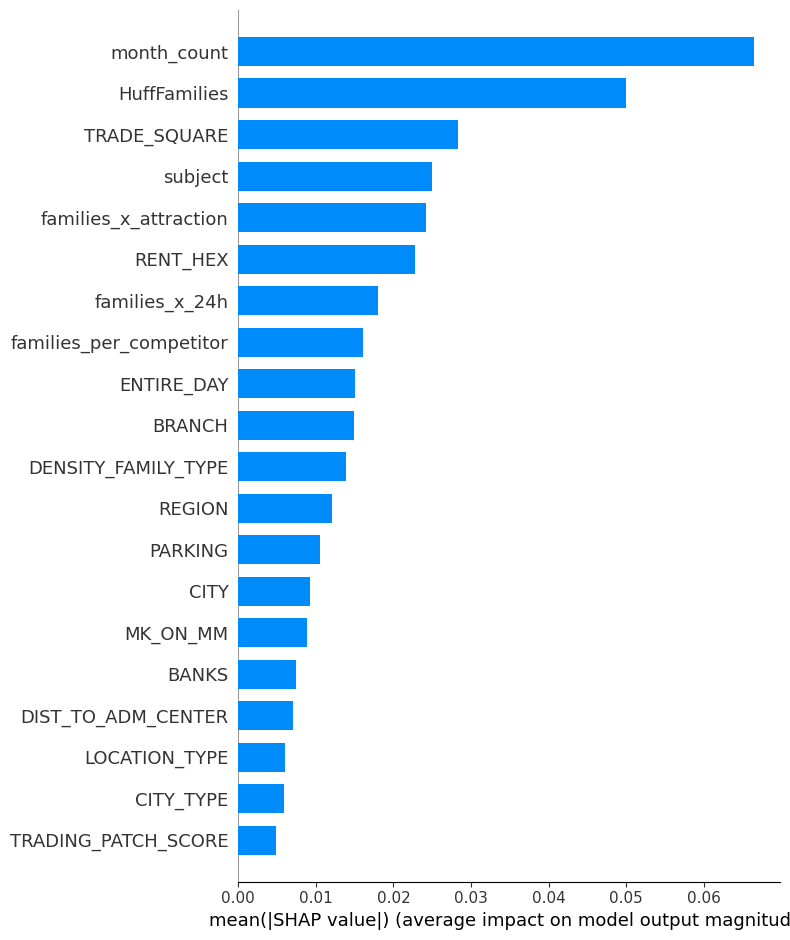

In [20]:
import shap
import matplotlib.pyplot as plt
# Используем TreeExplainer — он специально оптимизирован для CatBoost
explainer = shap.TreeExplainer(final_model)

# Считаем SHAP values для валидационной выборки (или для части train_full)
# Мы берем val[features], чтобы увидеть, как модель ведет себя на конкретных примерах
shap_values = explainer.shap_values(val[features])

# Инициализируем визуализацию в ноутбуке
shap.initjs()
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, val[features], plot_type="bar")

In [21]:
import pandas as pd
import numpy as np
import optuna
from catboost import CatBoostRegressor, Pool
from sklearn.metrics import mean_absolute_percentage_error

# 1. Загрузка и подготовка
train = pd.read_csv('train.csv')
val = pd.read_csv('val.csv')
holdout = pd.read_csv('holdout.csv')
TARGET_COL = ' target_2 '

for df in [train, val, holdout]:
    df['DIST_TO_ADM_CENTER'] = np.log1p(df['DIST_TO_ADM_CENTER'])
    df['TOTAL_RANK_COMPS_CANNIBALS'] = df['TOTAL_RANK_COMPS_CANNIBALS'].fillna(0).astype(np.int64)
    df['families_per_competitor'] = df['HuffFamilies'] / (df['TOTAL_RANK_COMPS_CANNIBALS'] + 1)
    df['attraction_per_square'] = df['TRADING_PATCH_SCORE'] / (df['TRADE_SQUARE'] + 1e-6)
    df['families_x_24h'] = df['HuffFamilies'] * df['ENTIRE_DAY']
    df['traffic_x_24h'] = df['ROUTES_CNT'] * df['ENTIRE_DAY']
    df['families_x_attraction'] = df['HuffFamilies'] * df['TRADING_PATCH_SCORE']

categorical = [
    'REGION', 'BRANCH', 'CITY', 'subject', 'SUBFRMT', 'HOSPITAL', 'KINDERGARTENS', 'BANKS', 
    'MK_ON_MM', 'CROSSWALK', 'CROSSROAD', 'DENSITY_FAMILY_TYPE', 'COLLEGES', 'IN_COAL_CITY', 
    'IN_OIL_CITY', 'CITY_TYPE', 'ON_DUPLICATE_ROAD', 'INSIDE_YARD', 'ON_INSIDE_DISTRICT_ROAD', 
    'ON_MAIN_CITY_ROAD', 'ON_INTERCITY_HIGHWAY', 'ENTRANCE_TO_DISTRICT', 'ON_DISTRICT_BOTTOM', 
    'HUB', 'ALCOHOL', 'TOBACCO', 'LOCATION_MARKET', 'STATIONS', 'TRC', 'METRO', 'LOCATION_PARK', 
    'MINI_TRC', 'TRADING_PATCH', 'ENTIRE_DAY', 'MORNING_ROADSIDE', 'SEA', 'FLOORS_TZ', 'SNT', 
    'LOCATION_TYPE', 'new_buildings', 'change_CA'
]
base_numeric = ['TRADE_SQUARE', 'HuffFamilies', 'HuffRelativeFamilies', 'ROUTES_CNT', 'huff_hotel', 'TRADING_PATCH_SCORE', 'RENT_HEX', 'HUFF_RANK_COMPS_CANNIBALS', 'TOTAL_RANK_COMPS_CANNIBALS', 'DIST_TO_ADM_CENTER', 'PARKING', 'month_count']
best_engineered = ['families_per_competitor', 'attraction_per_square', 'families_x_24h', 'traffic_x_24h', 'families_x_attraction']

drop_cols = ['ID', 'target_1', ' target_2 ']
features = list(dict.fromkeys([c for c in base_numeric + categorical + best_engineered if c in train.columns and c not in drop_cols]))
cat_features = [c for c in categorical if c in features]

y_train_log = np.log1p(train[TARGET_COL])
y_val_log = np.log1p(val[TARGET_COL])

# 2. Optuna: Оптимизация весов базовых признаков и квантиля
def objective(trial):
    # Диапазон квантиля от 20 до 25 по запросу
    alpha = trial.suggest_float("alpha", 0.20, 0.25)
    
    # Оптимизируем веса для указанных базовых признаков
    f_weights = {
        # Фиксированные веса дрейфа из прошлого запуска
        "TOTAL_RANK_COMPS_CANNIBALS": 1.4460511283530062,
        "SUBFRMT": 0.8753781502735977,
        "month_count": 0.15045527050736218,
        
        # Новые признаки для подбора весов
        "HuffFamilies": trial.suggest_float("w_hf", 0.5, 3.0),
        "TRADE_SQUARE": trial.suggest_float("w_ts", 0.5, 3.0),
        "subject": trial.suggest_float("w_subj", 0.1, 2.0),
        "HuffRelativeFamilies": trial.suggest_float("w_hrf", 0.5, 2.0)
    }
    
    params = {
        'loss_function': f'Quantile:alpha={alpha}',
        'depth': 5,
        'learning_rate': 0.042349436679478714,
        'iterations': 1500, 
        'l2_leaf_reg': 0.48192445522872746,
        'random_strength': 4.432552658816445,
        'feature_weights': f_weights,
        'eval_metric': 'MAPE',
        'random_seed': 42,
        'verbose': 0
    }
    
    model = CatBoostRegressor(**params)
    model.fit(
        Pool(train[features], y_train_log, cat_features=cat_features), 
        eval_set=Pool(val[features], y_val_log, cat_features=cat_features), 
        early_stopping_rounds=100
    )
    
    preds = np.expm1(model.predict(val[features]))
    return mean_absolute_percentage_error(val[TARGET_COL], np.maximum(preds, 0))

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=100)

# 3. Финальный замер и обучение
best_params = study.best_params
final_f_weights = {
    "TOTAL_RANK_COMPS_CANNIBALS": 1.4460511283530062,
    "SUBFRMT": 0.8753781502735977,
    "month_count": 0.15045527050736218,
    "HuffFamilies": best_params['w_hf'],
    "TRADE_SQUARE": best_params['w_ts'],
    "subject": best_params['w_subj'],
    "HuffRelativeFamilies": best_params['w_hrf']
}

# --- ШАГ 4.1: ЧЕСТНЫЙ ЗАМЕР МЕТРИКИ (БЕЗ ЛИКА) ---
val_model = CatBoostRegressor(
    loss_function=f"Quantile:alpha={best_params['alpha']}",
    depth=5,
    learning_rate=0.042349436679478714,
    iterations=3344,
    l2_leaf_reg=0.48192445522872746,
    random_strength=4.432552658816445,
    feature_weights=final_f_weights,
    eval_metric='MAPE',
    random_seed=42,
    verbose=0
)

val_model.fit(
    Pool(train[features], y_train_log, cat_features=cat_features),
    eval_set=Pool(val[features], y_val_log, cat_features=cat_features),
    early_stopping_rounds=100
)

clean_val_preds = np.maximum(np.expm1(val_model.predict(val[features])), 0)
print(f"\nCLEAN VALIDATION MAPE (No leak): {mean_absolute_percentage_error(val[TARGET_COL], clean_val_preds)}")
print(f"Best Optuna params: {best_params}")

# --- ШАГ 4.2: ФИНАЛЬНОЕ ОБУЧЕНИЕ НА ВСЕХ ДАННЫХ ---
train_full = pd.concat([train, val], axis=0).reset_index(drop=True)
y_full_log = np.log1p(train_full[TARGET_COL])

final_model = CatBoostRegressor(
    loss_function=f"Quantile:alpha={best_params['alpha']}",
    depth=5,
    learning_rate=0.042349436679478714,
    iterations=3344,
    l2_leaf_reg=0.48192445522872746,
    random_strength=4.432552658816445,
    feature_weights=final_f_weights,
    eval_metric='MAPE',
    random_seed=42,
    verbose=100
)

final_model.fit(Pool(train_full[features], y_full_log, cat_features=cat_features))

# 5. Итог
holdout_preds = np.maximum(np.expm1(final_model.predict(holdout[features])), 0)
pd.DataFrame({'id': holdout['ID'].values, 'PREDICT': holdout_preds}).to_csv('predictions.csv', index=False)

[I 2026-05-22 20:48:25,836] A new study created in memory with name: no-name-c3ed8d4c-b8d6-43ec-af8e-dcc81ddbffe3
[I 2026-05-22 20:48:33,202] Trial 0 finished with value: 0.1512225640874996 and parameters: {'alpha': 0.2124231846695214, 'w_hf': 1.0477644172559764, 'w_ts': 1.741870254234696, 'w_subj': 0.808888368382839, 'w_hrf': 1.9560671795205167}. Best is trial 0 with value: 0.1512225640874996.
[I 2026-05-22 20:48:40,730] Trial 1 finished with value: 0.15207979823144518 and parameters: {'alpha': 0.21006247137117914, 'w_hf': 1.2203624877601411, 'w_ts': 2.990451426147389, 'w_subj': 1.9529672377385259, 'w_hrf': 1.5262312590274403}. Best is trial 0 with value: 0.1512225640874996.
[I 2026-05-22 20:48:48,181] Trial 2 finished with value: 0.1504913655674147 and parameters: {'alpha': 0.23523120905730002, 'w_hf': 1.6031946609163121, 'w_ts': 1.3522925372600687, 'w_subj': 1.251358935991447, 'w_hrf': 1.5359484253569613}. Best is trial 2 with value: 0.1504913655674147.
[I 2026-05-22 20:48:55,500] T


CLEAN VALIDATION MAPE (No leak): 0.14899521031122018
Best Optuna params: {'alpha': 0.22849673319227315, 'w_hf': 1.7128597452183933, 'w_ts': 0.5026074447405465, 'w_subj': 1.5066552636736472, 'w_hrf': 1.221414730896079}
0:	learn: 0.0221664	total: 5.55ms	remaining: 18.6s
100:	learn: 0.0158026	total: 663ms	remaining: 21.3s
200:	learn: 0.0149477	total: 1.31s	remaining: 20.5s
300:	learn: 0.0145140	total: 2.02s	remaining: 20.4s
400:	learn: 0.0142326	total: 2.77s	remaining: 20.3s
500:	learn: 0.0140370	total: 3.51s	remaining: 19.9s
600:	learn: 0.0138689	total: 4.27s	remaining: 19.5s
700:	learn: 0.0137700	total: 4.99s	remaining: 18.8s
800:	learn: 0.0136716	total: 5.73s	remaining: 18.2s
900:	learn: 0.0136081	total: 6.46s	remaining: 17.5s
1000:	learn: 0.0135386	total: 7.21s	remaining: 16.9s
1100:	learn: 0.0134932	total: 7.96s	remaining: 16.2s
1200:	learn: 0.0134389	total: 8.68s	remaining: 15.5s
1300:	learn: 0.0133799	total: 9.4s	remaining: 14.8s
1400:	learn: 0.0133335	total: 10.1s	remaining: 14s


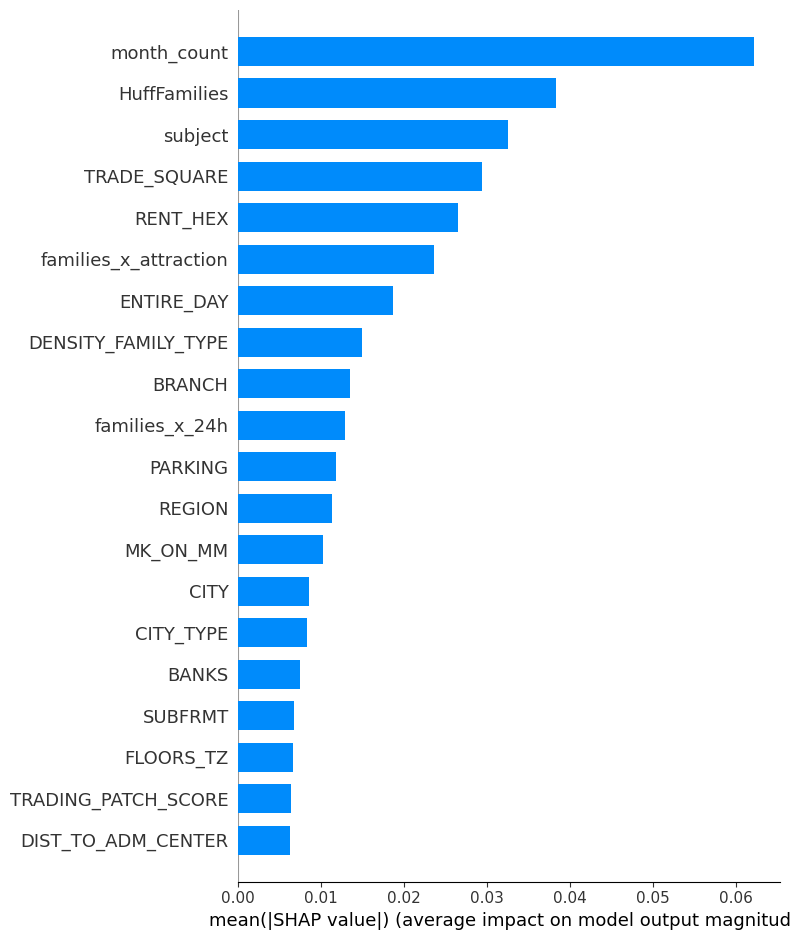

In [22]:
import shap
import matplotlib.pyplot as plt
# Используем TreeExplainer — он специально оптимизирован для CatBoost
explainer = shap.TreeExplainer(final_model)

# Считаем SHAP values для валидационной выборки (или для части train_full)
# Мы берем val[features], чтобы увидеть, как модель ведет себя на конкретных примерах
shap_values = explainer.shap_values(val[features])

# Инициализируем визуализацию в ноутбуке
shap.initjs()
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, val[features], plot_type="bar")

In [23]:
import pandas as pd
import numpy as np
import optuna
from catboost import CatBoostRegressor, Pool
from sklearn.metrics import mean_absolute_percentage_error

# 1. Загрузка и подготовка
train = pd.read_csv('train.csv')
val = pd.read_csv('val.csv')
holdout = pd.read_csv('holdout.csv')
TARGET_COL = ' target_2 '

for df in [train, val, holdout]:
    df['DIST_TO_ADM_CENTER'] = np.log1p(df['DIST_TO_ADM_CENTER'])
    df['TOTAL_RANK_COMPS_CANNIBALS'] = df['TOTAL_RANK_COMPS_CANNIBALS'].fillna(0).astype(np.int64)
    df['families_per_competitor'] = df['HuffFamilies'] / (df['TOTAL_RANK_COMPS_CANNIBALS'] + 1)
    df['attraction_per_square'] = df['TRADING_PATCH_SCORE'] / (df['TRADE_SQUARE'] + 1e-6)
    df['families_x_24h'] = df['HuffFamilies'] * df['ENTIRE_DAY']
    df['traffic_x_24h'] = df['ROUTES_CNT'] * df['ENTIRE_DAY']
    df['families_x_attraction'] = df['HuffFamilies'] * df['TRADING_PATCH_SCORE']

categorical = [
    'REGION', 'BRANCH', 'CITY', 'subject', 'SUBFRMT', 'HOSPITAL', 'KINDERGARTENS', 'BANKS', 
    'MK_ON_MM', 'CROSSWALK', 'CROSSROAD', 'DENSITY_FAMILY_TYPE', 'COLLEGES', 'IN_COAL_CITY', 
    'IN_OIL_CITY', 'CITY_TYPE', 'ON_DUPLICATE_ROAD', 'INSIDE_YARD', 'ON_INSIDE_DISTRICT_ROAD', 
    'ON_MAIN_CITY_ROAD', 'ON_INTERCITY_HIGHWAY', 'ENTRANCE_TO_DISTRICT', 'ON_DISTRICT_BOTTOM', 
    'HUB', 'ALCOHOL', 'TOBACCO', 'LOCATION_MARKET', 'STATIONS', 'TRC', 'METRO', 'LOCATION_PARK', 
    'MINI_TRC', 'TRADING_PATCH', 'ENTIRE_DAY', 'MORNING_ROADSIDE', 'SEA', 'FLOORS_TZ', 'SNT', 
    'LOCATION_TYPE', 'new_buildings', 'change_CA'
]
base_numeric = ['TRADE_SQUARE', 'HuffFamilies', 'HuffRelativeFamilies', 'ROUTES_CNT', 'huff_hotel', 'TRADING_PATCH_SCORE', 'RENT_HEX', 'HUFF_RANK_COMPS_CANNIBALS', 'TOTAL_RANK_COMPS_CANNIBALS', 'DIST_TO_ADM_CENTER', 'PARKING', 'month_count']
best_engineered = ['families_per_competitor', 'attraction_per_square', 'families_x_24h', 'traffic_x_24h', 'families_x_attraction']

drop_cols = ['ID', 'target_1', ' target_2 ']
features = list(dict.fromkeys([c for c in base_numeric + categorical + best_engineered if c in train.columns and c not in drop_cols]))
cat_features = [c for c in categorical if c in features]

y_train_log = np.log1p(train[TARGET_COL])
y_val_log = np.log1p(val[TARGET_COL])

# 2. Optuna: Тотальная оптимизация весов и гиперпараметров
def objective(trial):
    # Ультра-узкие диапазоны для весов признаков
    f_weights = {
        "TOTAL_RANK_COMPS_CANNIBALS": trial.suggest_float("w_trcc", 1.40, 1.50),
        "SUBFRMT": trial.suggest_float("w_sub", 0.82, 0.92),
        "month_count": trial.suggest_float("w_mc", 0.10, 0.20),
        "HuffFamilies": trial.suggest_float("w_hf", 1.65, 1.80),
        "TRADE_SQUARE": trial.suggest_float("w_ts", 0.45, 0.55),
        "subject": trial.suggest_float("w_subj", 1.45, 1.55),
        "HuffRelativeFamilies": trial.suggest_float("w_hrf", 1.18, 1.28)
    }
    
    # Полный набор гиперпараметров модели
    cb_params = {
        'loss_function': f'Quantile:alpha={trial.suggest_float("alpha", 0.21, 0.24)}',
        'depth': trial.suggest_int("depth", 4, 7),
        'learning_rate': trial.suggest_float("learning_rate", 0.01, 0.05, log=True),
        'l2_leaf_reg': trial.suggest_float("l2_leaf_reg", 0.5, 15.0, log=True),
        'random_strength': trial.suggest_float("random_strength", 1.0, 10.0),
        'rsm': trial.suggest_float("rsm", 0.7, 1.0), # feature subsampling
        'subsample': trial.suggest_float("subsample", 0.6, 0.9), # row subsampling
        'bootstrap_type': 'Bernoulli',
        'iterations': 1500, 
        'feature_weights': f_weights,
        'eval_metric': 'MAPE',
        'random_seed': 42,
        'verbose': 0
    }
    
    model = CatBoostRegressor(**cb_params)
    model.fit(
        Pool(train[features], y_train_log, cat_features=cat_features), 
        eval_set=Pool(val[features], y_val_log, cat_features=cat_features), 
        early_stopping_rounds=100
    )
    
    preds = np.expm1(model.predict(val[features]))
    return mean_absolute_percentage_error(val[TARGET_COL], np.maximum(preds, 0))

# Ставим 100 итераций для поиска в узких диапазонах
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=120)

# 3. Подготовка финальных параметров
best = study.best_params
final_f_weights = {
    "TOTAL_RANK_COMPS_CANNIBALS": best['w_trcc'],
    "SUBFRMT": best['w_sub'],
    "month_count": best['w_mc'],
    "HuffFamilies": best['w_hf'],
    "TRADE_SQUARE": best['w_ts'],
    "subject": best['w_subj'],
    "HuffRelativeFamilies": best['w_hrf']
}

final_cb_params = {
    'loss_function': f"Quantile:alpha={best['alpha']}",
    'depth': best['depth'],
    'learning_rate': best['learning_rate'],
    'l2_leaf_reg': best['l2_leaf_reg'],
    'random_strength': best['random_strength'],
    'rsm': best['rsm'],
    'subsample': best['subsample'],
    'bootstrap_type': 'Bernoulli',
    'iterations': 4000, # Увеличиваем итерации для финала
    'feature_weights': final_f_weights,
    'eval_metric': 'MAPE',
    'random_seed': 42,
    'verbose': 100
}

# 4. Финальный замер MAPE (честный)
val_model = CatBoostRegressor(**final_cb_params)
val_model.fit(Pool(train[features], y_train_log, cat_features=cat_features), 
              eval_set=Pool(val[features], y_val_log, cat_features=cat_features), 
              early_stopping_rounds=200)

clean_val_preds = np.maximum(np.expm1(val_model.predict(val[features])), 0)
print(f"\nFINAL HONEST VALIDATION MAPE: {mean_absolute_percentage_error(val[TARGET_COL], clean_val_preds)}")

# 5. Обучение на всех данных (Leak mode for submission)
train_full = pd.concat([train, val], axis=0).reset_index(drop=True)
y_full_log = np.log1p(train_full[TARGET_COL])

final_model = CatBoostRegressor(**final_cb_params)
final_model.fit(Pool(train_full[features], y_full_log, cat_features=cat_features))

# 6. Предсказание для Holdout
holdout_preds = np.maximum(np.expm1(final_model.predict(holdout[features])), 0)
pd.DataFrame({'id': holdout['ID'].values, 'PREDICT': holdout_preds}).to_csv('predictions.csv', index=False)

print("Best Parameters Found:", best)

[I 2026-05-22 21:09:26,359] A new study created in memory with name: no-name-2385dcfd-1814-4aab-a53b-1bd703eb95c2
[I 2026-05-22 21:09:35,722] Trial 0 finished with value: 0.15066286498649145 and parameters: {'w_trcc': 1.4712814994946897, 'w_sub': 0.8907500394864304, 'w_mc': 0.11205705306081869, 'w_hf': 1.736548944605464, 'w_ts': 0.504796125685662, 'w_subj': 1.4501195659508, 'w_hrf': 1.2383829731904459, 'alpha': 0.2333133233066998, 'depth': 6, 'learning_rate': 0.024996040164134044, 'l2_leaf_reg': 7.7234769758523125, 'random_strength': 5.889897227470081, 'rsm': 0.9229292188766092, 'subsample': 0.8123651770992104}. Best is trial 0 with value: 0.15066286498649145.
[I 2026-05-22 21:09:40,937] Trial 1 finished with value: 0.15033572733621853 and parameters: {'w_trcc': 1.4632051201882523, 'w_sub': 0.9153118644474776, 'w_mc': 0.19867941879445886, 'w_hf': 1.6845005947511287, 'w_ts': 0.4654334971767806, 'w_subj': 1.537671198390903, 'w_hrf': 1.1998890492195307, 'alpha': 0.23269605158269108, 'dept

0:	learn: 0.0221302	test: 0.0180210	best: 0.0180210 (0)	total: 6.74ms	remaining: 26.9s
100:	learn: 0.0158060	test: 0.0137062	best: 0.0137062 (100)	total: 534ms	remaining: 20.6s
200:	learn: 0.0148980	test: 0.0132766	best: 0.0132766 (200)	total: 1.09s	remaining: 20.6s
300:	learn: 0.0143934	test: 0.0129333	best: 0.0129333 (300)	total: 1.69s	remaining: 20.8s
400:	learn: 0.0141236	test: 0.0127916	best: 0.0127916 (400)	total: 2.3s	remaining: 20.7s
500:	learn: 0.0139389	test: 0.0127127	best: 0.0127127 (500)	total: 2.95s	remaining: 20.6s
600:	learn: 0.0137845	test: 0.0126501	best: 0.0126501 (600)	total: 3.61s	remaining: 20.4s
700:	learn: 0.0136455	test: 0.0126003	best: 0.0126001 (699)	total: 4.26s	remaining: 20s
800:	learn: 0.0135099	test: 0.0125621	best: 0.0125621 (800)	total: 4.94s	remaining: 19.7s
900:	learn: 0.0134090	test: 0.0125316	best: 0.0125316 (900)	total: 5.62s	remaining: 19.3s
1000:	learn: 0.0133085	test: 0.0125070	best: 0.0125006 (986)	total: 6.27s	remaining: 18.8s
1100:	learn: 0.

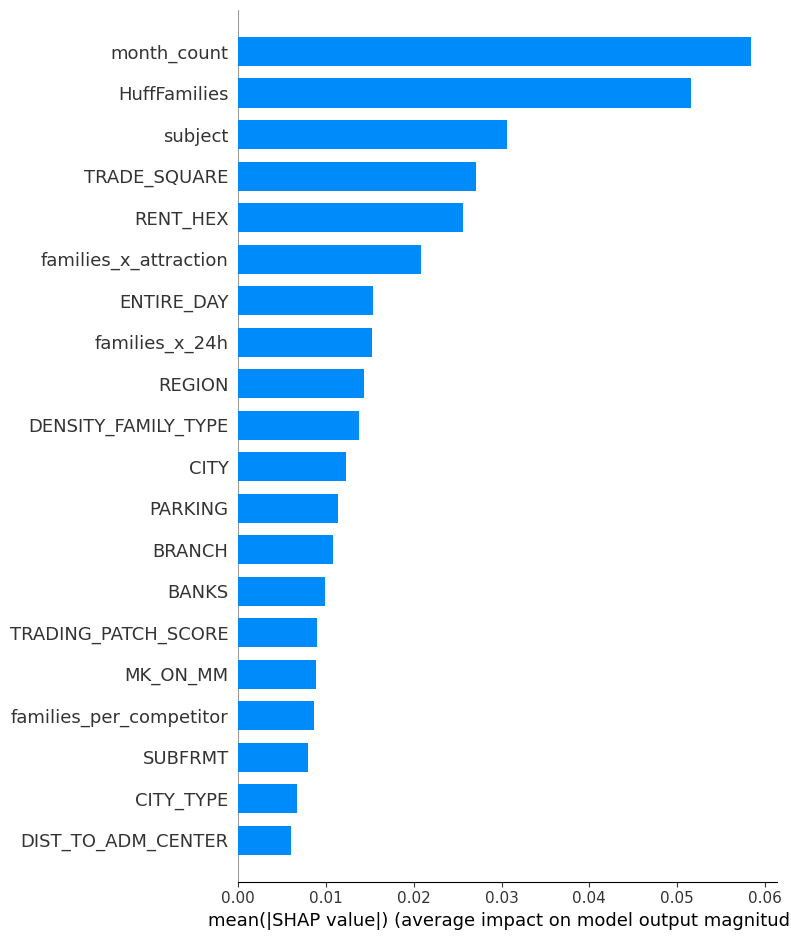

In [24]:
import shap
import matplotlib.pyplot as plt
# Используем TreeExplainer — он специально оптимизирован для CatBoost
explainer = shap.TreeExplainer(final_model)

# Считаем SHAP values для валидационной выборки (или для части train_full)
# Мы берем val[features], чтобы увидеть, как модель ведет себя на конкретных примерах
shap_values = explainer.shap_values(val[features])

# Инициализируем визуализацию в ноутбуке
shap.initjs()
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, val[features], plot_type="bar")